# 04 — Is the preparatory code stable, or does it change over time?

**This notebook answers the project's third question:**

> **Q3.** Is the neural representation of intended direction *stable* throughout the
> preparatory period, or does the population code *change* as time passes?

## Why notebook 03 cannot answer this

Notebook 03 showed that direction is decodable at every moment of the delay. It is tempting
to conclude that the brain holds a steady representation of the intended movement. That
conclusion does not follow.

At each time point we trained a **separate** classifier. A separate classifier is free to
use a completely different set of weights — a different pattern across channels — at every
moment. So a flat, sustained accuracy curve is equally consistent with two very different
pictures:

```
STABLE                                  DYNAMIC
the same population pattern             the pattern keeps changing, but at
held steady through the delay           each instant it is still decodable

channel A  ████████████████             channel A  ███▁▁▁▁▁▁███████
channel B  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁             channel B  ▁▁▁████████▁▁▁▁▁
channel C  ██████████████████           channel C  ▁▁▁▁▁▁▁▁███▁▁▁▁▁

-> a decoder trained early                -> a decoder trained early
   still works late                          fails when tested late
```

Both give the same accuracy-over-time curve. Telling them apart requires a different
experiment.

## Temporal generalisation

The method (King & Dehaene, 2014) is simple: **train at one time, test at another.**

For every pair of times $(t_i, t_j)$: train the decoder on training trials at time $t_i$,
then evaluate it on **held-out** trials at time $t_j$. The result is a matrix

$$A(t_i, t_j) = \text{cross-validated accuracy}$$

which we read as a heatmap. The diagonal ($t_i = t_j$) reproduces notebook 03's curve. The
off-diagonal is the new information.

**How to read the resulting heatmap:**

| pattern | interpretation |
|---|---|
| broad square block of high accuracy | **stable** code — one pattern persists, a decoder trained anywhere in the block works anywhere else in it |
| narrow band hugging the diagonal | **dynamic** code — direction stays decodable, but the pattern carrying it keeps changing |
| separate blocks with a gap between them | two distinct regimes (e.g. a preparatory code and a separate movement code) |
| off-diagonal *below chance* | the code has **reversed** — the same channels carry opposite meanings at the two times |

A useful intuition for the dynamic case: the population state may be travelling along a
trajectory that keeps direction information intact at every point, while the *axis* along
which directions separate rotates as it goes.

In [1]:
import sys
import time
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src import plotting
from src.data_loading import load_trial_data
from src.decoding import make_cv, make_pipeline
from src.preprocessing import (analysis_time_index, check_class_balance,
                               direction_labels, pick_feature, select_trials)

np.random.seed(config.RANDOM_STATE)
plotting.use_house_style()
config.ensure_output_dirs()

td = load_trial_data(config.PARTICIPANT, config.ALIGNMENT, config.FIGURE,
                     config.candidate_data_dirs())

features = pick_feature(td, config.FEATURE_TYPE)
keep, report = select_trials(features, td.delay, td.no_go,
                             config.MIN_DELAY_S, config.GO_TRIALS_ONLY)
print(report)

labels_all, centres = direction_labels(td.target, td.start, config.N_DIRECTIONS)
X = features[keep]
y = labels_all[keep]
blocks = td.block[keep]
t_ms = td.t_ms
check_class_balance(y, config.N_DIRECTIONS, config.MIN_TRIALS_PER_DIRECTION)
go_cue_times_ms = sorted((np.unique(td.delay[keep]) * 1000).tolist())
print(f"\nX: {X.shape}")

Trial selection
  starting trials              : 385
  dropped, non-finite features : 0
  dropped, non-finite delay    : 0
  dropped, delay < 0.8 s        : 0
  dropped, no-go trials        : 121
  --> kept                     : 264

X: (264, 150, 61)


## 1. The same folds as notebook 03

For the diagonal of this matrix to be comparable with notebook 03's curve, the two analyses
must use *identical* splits — not merely similar-looking ones. So notebook 03 saved its
folds, and we load them here, checking a fingerprint of the trial-selection mask to be sure
they were built for exactly this set of trials.

If the file is missing we regenerate the folds from the same seed and say so.

In [2]:
splits_path = config.TABLES_DIR / "cv_splits.npz"
trial_fingerprint = zlib.crc32(keep.tobytes())   # must match notebook 03
cv_plan = None

if splits_path.exists():
    saved = np.load(splits_path, allow_pickle=True)
    saved_fp = int(saved["trial_fingerprint"])
    if saved_fp == trial_fingerprint:
        n_saved = int(saved["n_splits"])
        splits = [(saved[f"train_{i}"], saved[f"test_{i}"]) for i in range(n_saved)]
        scheme = str(saved["scheme"])
        print(f"loaded the folds from notebook 03 ({splits_path.name})")
        print(f"  scheme      : {scheme}")
        print(f"  folds       : {n_saved}")
        print(f"  fingerprint : {saved_fp} == {trial_fingerprint}  -> same trial set")

        class _Loaded:
            pass
        cv_plan = _Loaded()
        cv_plan.splits, cv_plan.scheme, cv_plan.n_splits = splits, scheme, n_saved
    else:
        print(f"NOTE: {splits_path.name} was built for a different trial set "
              f"(fingerprint {saved_fp} != {trial_fingerprint}).")
        print("      Regenerating folds from the seed instead.")

if cv_plan is None:
    print("NOTE: regenerating the folds from RANDOM_STATE "
          "(run notebook 03 first to share them exactly).")
    cv_plan = make_cv(y, blocks, config.N_SPLITS, config.RANDOM_STATE,
                      n_classes=config.N_DIRECTIONS)
    print(cv_plan)

loaded the folds from notebook 03 (cv_splits.npz)
  scheme      : StratifiedGroupKFold
  folds       : 5
  fingerprint : 1884526301 == 1884526301  -> same trial set


## 2. ⚠️ The detail that makes or breaks this analysis

There is one way to get temporal generalisation subtly, invisibly wrong, and it is worth
more attention than the loop itself.

The decoder pipeline has two fitted parts: a **scaler** (per-channel mean and SD) and a
**classifier** (the weights). Both are fitted at the training time $t_i$. The question is
what to do at test time $t_j$.

**Wrong:** standardise the test data using statistics computed at $t_j$.

**Right:** apply the scaler fitted at $t_i$ — its means and SDs — to the test data at $t_j$.

Why it matters so much here: firing rates change over the trial. Re-standardising at each
test time would *remove that change*, silently re-centring every time point onto the same
mean. But the drift of the population pattern across time is **exactly the thing this
analysis is trying to measure**. Re-standardising per test time would erase the evidence
for a dynamic code and manufacture the appearance of a stable one.

The rule: **one scaler and one classifier per (fold, training time), applied unchanged at
every test time.**

```
for each fold:
    for each train time t_i:
        fit scaler   on X[train trials, t_i]      <- fitted ONCE
        fit classifier on scaled X[train, t_i]    <- fitted ONCE
        for each test time t_j:
            transform X[held-out trials, t_j] with THAT scaler
            predict, and score
```

## 3. The double loop

One implementation note. Written naively this is `n_folds × n_times × n_times` predict
calls — over 110,000 here. Instead, for each (fold, train time) we reshape the held-out
trials across *all* test times into one big `(n_test × n_times, n_channels)` block,
transform it with the training-time scaler, and predict it in a single call. That is
arithmetically identical and much faster; the number of *fits* is unchanged at
`n_folds × n_times`.

In [3]:
time_idx = analysis_time_index(t_ms, config.TG_STEP_MS)
t_used = t_ms[time_idx]
n_times = time_idx.size
n_folds = cv_plan.n_splits

# X restricted to the analysis grid: (trials, n_times, channels)
Xg = X[:, time_idx, :]
n_channels = Xg.shape[2]

# accuracy per fold, per train time, per test time
acc_folds = np.zeros((n_folds, n_times, n_times))

print(f"{n_folds} folds x {n_times} train times = {n_folds * n_times} model fits, "
      f"each scored at {n_times} test times")
t0 = time.time()

for fi, (train_idx, test_idx) in enumerate(cv_plan.splits):
    # Held-out trials at every test time, flattened so one predict() call covers
    # the whole row of the matrix: (n_test * n_times, n_channels)
    X_test_all = Xg[test_idx].reshape(-1, n_channels)
    y_test = y[test_idx]
    n_test = test_idx.size

    for ti in range(n_times):
        # Fit scaler AND classifier at the training time only.
        model = make_pipeline(C=config.LOGREG_C, random_state=config.RANDOM_STATE)
        model.fit(Xg[train_idx, ti, :], y[train_idx])

        # Apply that same fitted pipeline - crucially, that same scaler - to the
        # held-out trials at every test time. Nothing is re-fitted here.
        pred = model.predict(X_test_all).reshape(n_test, n_times)

        # pred[:, tj] are this model's predictions at test time tj
        acc_folds[fi, ti, :] = (pred == y_test[:, None]).mean(axis=0)

    print(f"  fold {fi} done ({time.time() - t0:.0f}s elapsed)")

acc_matrix = acc_folds.mean(axis=0)      # (train time, test time)
print(f"\ndone in {time.time() - t0:.0f}s. matrix shape {acc_matrix.shape}")

5 folds x 150 train times = 750 model fits, each scored at 150 test times
  fold 0 done (2s elapsed)
  fold 1 done (4s elapsed)
  fold 2 done (6s elapsed)
  fold 3 done (7s elapsed)
  fold 4 done (9s elapsed)

done in 9s. matrix shape (150, 150)


In [4]:
# Sanity check: the diagonal of this matrix must reproduce notebook 03's curve,
# since train time == test time is exactly the same computation.
diag = np.diag(acc_matrix)
csv_path = config.TABLES_DIR / "time_resolved_decoding.csv"
if csv_path.exists() and config.TG_STEP_MS == config.DECODE_STEP_MS:
    nb03 = (pd.read_csv(csv_path).groupby("t_ms")["accuracy"].mean()
            .reindex(t_used).to_numpy())
    max_diff = np.nanmax(np.abs(diag - nb03))
    print(f"max |diagonal - notebook 03 curve| = {max_diff:.2e}")
    print("--> identical" if max_diff < 1e-9 else
          "--> DIFFERENT: the folds or the trial set do not match.")
else:
    print("notebook 03 results not available for comparison (or a different time grid).")

max |diagonal - notebook 03 curve| = 1.11e-16
--> identical


## 4. The generalisation matrix

Colour diverges around chance, so grey means "no directional information" and the eye can
read the extent of the informative region directly. The dashed diagonal is where training
and test times coincide.

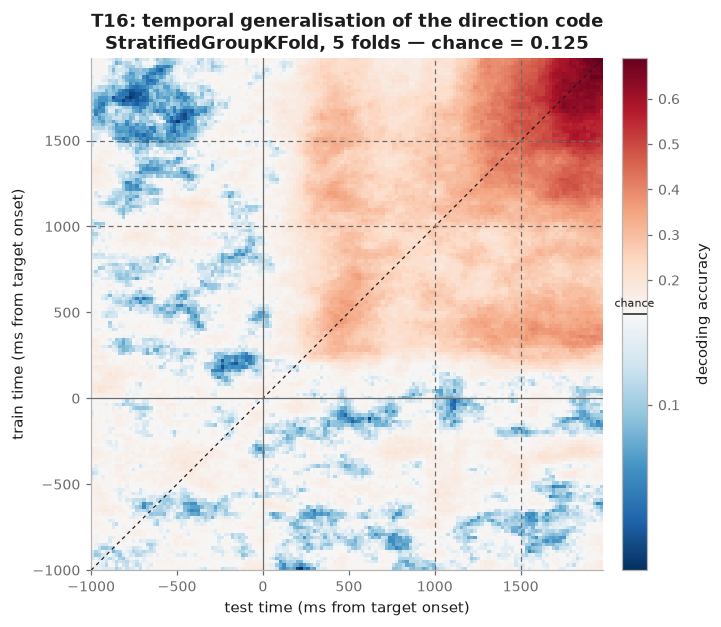

In [5]:
fig = plotting.plot_temporal_generalization(
    acc_matrix, t_used, config.CHANCE_LEVEL,
    go_cue_times_ms=go_cue_times_ms,
    prep_window_ms=config.PREP_WINDOW_MS,
    title=f"{config.PARTICIPANT}: temporal generalisation of the direction code\n"
          f"{cv_plan.scheme}, {n_folds} folds — chance = {config.CHANCE_LEVEL:.3f}",
)
fig.savefig(config.FIGURES_DIR / "temporal_generalization.png", bbox_inches="tight")
plt.show()

## 5. Quantifying stability

The heatmap is read qualitatively, but numbers make the impression concrete.

**Stability index.** Mean off-diagonal accuracy within a window, divided by the mean
diagonal accuracy over the same window. 1.0 means a decoder transfers across the window as
well as it works at its own training time. The value a *fully dynamic* code would give is
not 0 but `chance / diagonal`, so we print that as the comparison point.

> **A confound to avoid.** The obvious window is the whole preparatory period, 0 to 800 ms.
> But at t = 0 the target has only just appeared and there is essentially no directional
> information yet, so a decoder trained there fails everywhere — through lack of signal, not
> through instability. Including such time points drags the off-diagonal down and makes a
> stable code look dynamic. We therefore report both: the full window, and a window
> restricted to training times where the decoder demonstrably works.

In [6]:
def stability_report(lo, hi, name):
    idx = np.where((t_used >= lo) & (t_used <= hi))[0]
    sub = acc_matrix[np.ix_(idx, idx)]
    d = float(np.mean(np.diag(sub)))
    o = float(sub[~np.eye(len(idx), dtype=bool)].mean())
    print(f"{name}  [{lo:.0f} to {hi:.0f} ms, {len(idx)} time points]")
    print(f"   mean on-diagonal  : {d:.3f}")
    print(f"   mean off-diagonal : {o:.3f}")
    print(f"   stability index   : {o / d:.3f}   "
          f"(a fully dynamic code would give {config.CHANCE_LEVEL / d:.3f})\n")
    return idx

_ = stability_report(0, config.PREP_WINDOW_MS[1], "whole preparatory window")
prep_i = stability_report(300, config.PREP_WINDOW_MS[1],
                          "informative preparatory window")
if t_used[-1] > 1200:
    _ = stability_report(1200, t_used[-1], "movement period")

whole preparatory window  [0 to 800 ms, 41 time points]
   mean on-diagonal  : 0.243
   mean off-diagonal : 0.206
   stability index   : 0.848   (a fully dynamic code would give 0.515)

informative preparatory window  [300 to 800 ms, 26 time points]
   mean on-diagonal  : 0.294
   mean off-diagonal : 0.277
   stability index   : 0.941   (a fully dynamic code would give 0.425)

movement period  [1200 to 1980 ms, 40 time points]
   mean on-diagonal  : 0.506
   mean off-diagonal : 0.467
   stability index   : 0.923   (a fully dynamic code would give 0.247)



In [7]:
# Does a decoder trained during preparation still work during movement, and vice versa?
move_i = np.where((t_used >= 1500) & (t_used <= t_used[-1]))[0]
if move_i.size:
    print("Cross-period generalisation")
    print(f"  train preparation (300-800 ms) -> test movement (1500+ ms) : "
          f"{acc_matrix[np.ix_(prep_i, move_i)].mean():.3f}")
    print(f"  train movement (1500+ ms) -> test preparation (300-800 ms) : "
          f"{acc_matrix[np.ix_(move_i, prep_i)].mean():.3f}")
    print(f"  (preparatory diagonal for comparison                       : "
          f"{np.diag(acc_matrix)[prep_i].mean():.3f})")

Cross-period generalisation
  train preparation (300-800 ms) -> test movement (1500+ ms) : 0.309
  train movement (1500+ ms) -> test preparation (300-800 ms) : 0.244
  (preparatory diagonal for comparison                       : 0.294)


**Generalisation profile.** The same question along one axis: for decoders trained at
informative preparatory times, how does accuracy fall off as the test time moves away? A
perfectly stable code gives a flat profile; a perfectly dynamic one, a sharp peak at zero lag.

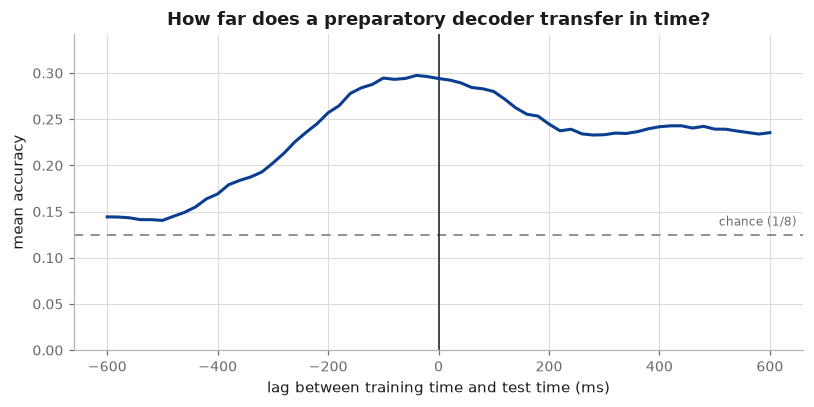

  lag    0 ms : 0.294
  lag  100 ms : 0.280
  lag  200 ms : 0.245
  lag  300 ms : 0.233
  lag  400 ms : 0.242
  lag  500 ms : 0.239


In [8]:
prep_mask = np.zeros(n_times, dtype=bool)
prep_mask[prep_i] = True

lags_ms, lag_means = [], []
step = float(np.round(np.diff(t_used)[0]))
max_lag = int(round(600 / step))
for lag in range(-max_lag, max_lag + 1):
    vals = [acc_matrix[i, i + lag] for i in prep_i if 0 <= i + lag < n_times]
    if vals:
        lags_ms.append(lag * step)
        lag_means.append(np.mean(vals))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.axhline(config.CHANCE_LEVEL, color=plotting.CHANCE_COLOR, lw=1.2, ls=(0, (5, 4)))
ax.annotate("chance (1/8)", xy=(1.0, config.CHANCE_LEVEL),
            xycoords=("axes fraction", "data"), xytext=(-4, 4),
            textcoords="offset points", fontsize=8,
            color=plotting.INK_MUTED, ha="right", va="bottom")
ax.axvline(0, color=plotting.INK, lw=1.0)
ax.plot(lags_ms, lag_means, color=plotting.ACCENT)
ax.set_xlabel("lag between training time and test time (ms)")
ax.set_ylabel("mean accuracy")
ax.set_title("How far does a preparatory decoder transfer in time?")
ax.set_ylim(0, max(lag_means) * 1.15)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "generalization_by_lag.png", bbox_inches="tight")
plt.show()

for probe in [0, 100, 200, 300, 400, 500]:
    if probe in lags_ms:
        print(f"  lag {probe:4.0f} ms : {lag_means[lags_ms.index(probe)]:.3f}")

## 6. Save the results

In [9]:
np.save(config.TABLES_DIR / "temporal_generalization.npy", acc_matrix)
np.save(config.TABLES_DIR / "temporal_generalization_folds.npy", acc_folds)
np.save(config.TABLES_DIR / "temporal_generalization_times.npy", t_used)

for name in ["temporal_generalization.npy", "temporal_generalization_folds.npy",
             "temporal_generalization_times.npy"]:
    print(f"saved -> {config.TABLES_DIR / name}")

print(f"\nmatrix {acc_matrix.shape}, per-fold stack {acc_folds.shape}")
print(f"range: {acc_matrix.min():.3f} to {acc_matrix.max():.3f}")

saved -> C:\Users\gilad\Intracortical_project\intracortical-prep-decoding\results\tables\temporal_generalization.npy
saved -> C:\Users\gilad\Intracortical_project\intracortical-prep-decoding\results\tables\temporal_generalization_folds.npy
saved -> C:\Users\gilad\Intracortical_project\intracortical-prep-decoding\results\tables\temporal_generalization_times.npy

matrix (150, 150), per-fold stack (5, 150, 150)
range: 0.054 to 0.690


## Answering Q3

*(Interpretation of the T16 run committed with this notebook.)*

### The preparatory code is largely stable

| window | on-diagonal | off-diagonal | stability index | fully-dynamic value |
|---|---|---|---|---|
| whole preparatory (0–800 ms) | 0.243 | 0.206 | 0.848 | 0.515 |
| **informative preparatory (300–800 ms)** | 0.294 | **0.277** | **0.941** | 0.425 |
| movement (1200–1980 ms) | 0.506 | 0.467 | 0.923 | 0.247 |

A decoder trained at one preparatory moment and tested at a *different* preparatory moment
retains **94%** of the accuracy it achieves at its own training time. If the population code
were rotating away from itself, this number would head towards 0.425; instead it sits close
to 1. The lag profile says the same thing: accuracy falls only from 0.294 at zero lag to
about 0.24 at half a second of lag, then flattens rather than collapsing to chance.

The heatmap shows why: not a narrow diagonal band, but a **broad square block** of
above-chance accuracy spanning roughly 250 ms onward on both axes. That is the signature of
a stable representation — one population pattern, established shortly after the target
appears and then *held*.

This connects back to notebook 03's curve. Accuracy there peaked around 460 ms and then
declined during the delay, which could have meant the code was drifting away. The matrix says
otherwise: the *pattern* stays the same, the population simply expresses it less strongly as
the wait continues. Those are different claims, and only the train×test analysis can separate
them — which is precisely why notebook 03 could not answer this question.

### An unplanned bonus: preparation generalises into movement

The matrix answers a question we had not intended to ask yet. A decoder trained during
**preparation** (300–800 ms) and tested during **movement** (1500 ms onward) scores **0.309**
— slightly *better* than the same decoder scores during preparation itself (0.294). The
reverse direction works too: a movement-trained decoder scores 0.244 back in the delay.

So the directional axis established during preparation is not discarded when the movement is
released; execution activity lies substantially along the same axis, expressed more strongly.
This is a genuinely encouraging result for preparatory BCI control — a decoder calibrated on
preparation would not be starting from scratch at movement onset — and it previews the
preparation → execution analysis using `fig1_T16_move.h5`.

Two honest caveats on that comparison. First, the movement period contains far more
directional information overall (diagonal 0.506 vs 0.294), so a *partial* overlap of axes can
still yield a high cross-period score. Second, this is a within-file comparison across time
within the same trials; the proper test uses the movement-aligned file with held-out trials,
which is a separate analysis.

### What remains uncertain

- **Timing, again.** The acausal σ = 100 ms smoothing blurs activity across ±200 ms. Some of
  the near-diagonal breadth is guaranteed by the smoothing alone, so the *minimum* width of
  the stable block is not informative. The broad block extending over more than a second is
  far wider than the smoothing can explain, which is why the stability conclusion survives.
- **Stability of what?** A high stability index means the *linear decision boundary*
  transfers. That is a weaker claim than "the population state is unchanged" — the state can
  move a great deal as long as it moves in directions the classifier ignores.
- **Below-chance corners.** Some regions where training and testing straddle target onset dip
  below 12.5%. With ~40–90 test trials per fold these are within noise of chance; do not read
  them as evidence of code reversal without a permutation test.

---

## Now try this

1. **Make the wrong version and compare.** Inside the double loop, replace the test-time
   transform with a scaler fitted at the *test* time (`StandardScaler().fit_transform(...)`
   on the test-time data). How does the matrix change? This is the single most instructive
   thing you can do with this notebook — it shows how a plausible-looking line of code
   fabricates a conclusion.
2. **Coarsen the grid.** Set `TG_STEP_MS = 60` in `config.py`. The matrix is computed ~3×
   faster. Does any conclusion change? If not, what does that tell you about how much
   independent information neighbouring 20 ms bins carry, given σ = 100 ms smoothing?
3. **Cross the go cue.** Look at the block of the matrix where training time is in the delay
   and test time is after movement onset. Does a preparatory decoder work during movement?
   This previews the preparation → execution question.
4. **Try the no-go trials.** With `GO_TRIALS_ONLY = False`, no-go trials stay preparatory
   for the whole epoch. Does the stable block extend further in time when no movement ever
   interrupts it?